In [1]:
import pandas as pd
import numpy as np
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.semi_supervised import LabelSpreading

import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("data/raw/7282_1.csv")

# giảm dữ liệu để chạy nhanh
df = df.sample(8000, random_state=42)

df.head()

,address,categories,city,country,latitude,longitude,name,postalCode,province,reviews.date,reviews.dateAdded,reviews.doRecommend,reviews.id,reviews.rating,reviews.text,reviews.title,reviews.userCity,reviews.username,reviews.userProvince
11107,301 Reserve Ave,"Luxury Hotels,Restaurants,Hotels & Motels,Lodg...",Roanoke,US,37.256149,-79.947005,Cambria Hotel & Suites,24016,VA,2015-10-26T00:00:00Z,2016-10-13T13:22:03Z,NaN,NaN,5.0,This upscale Choice property was perfect for o...,Base for Roanoke visit,Tucson,Paul G,AZ
29089,355 Santana Row,"Hotels,Hotel, Bar, and Hotel Bar",San Jose,US,37.320980,-121.947900,Hotel Valencia Santana Row,95128,CA,2015-12-26T00:00:00Z,2016-11-17T15:13:00Z,NaN,NaN,3.0,I've stayed two nights for a business trip at ...,"Good location, large rooms, but old bathroom",The Netherlands,Joris L,MI
15961,2120 Claude Bailey Pkwy,"Travel & Transport,Hotels & Motels",Princeton,US,41.368016,-89.456966,Americinn Lodge Suites Princeton,61356,IL,2016-03-21T00:00:00Z,2017-01-08T18:34:34Z,NaN,NaN,1.0,From the warm greeting at check-in to the serv...,overall Very satisfied,Lewistown,Kenneth N,NaN
13555,19 Sombrero Blvd,Hotels,Marathon,US,24.711823,-81.080550,Sombrero Resort and Marina,33050,Grassy Key,2016-01-23T00:00:00Z,2016-11-05T19:13:20Z,NaN,NaN,2.0,Hotel is old. This might be section due to be ...,Avoid in current condition!,Boca Raton,H.Chris,FL
9008,2512 W Lincolnway,Hotels,Cheyenne,US,41.119150,-104.849490,Americas Best Value Inn,82001,WY,2016-07-24T00:00:00Z,2016-11-21T23:27:41Z,NaN,NaN,3.0,"Not the nicest motel in the world, but it was ...",Good value for the money,NaN,A Traveler,NaN


In [3]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

df["clean_text"] = df["reviews.text"].apply(clean_text)

In [4]:
tfidf = TfidfVectorizer(max_features=500)

X = tfidf.fit_transform(df["clean_text"])

In [5]:
df["sentiment"] = df["reviews.rating"].apply(
    lambda x: 1 if x >= 4 else 0
)

y = df["sentiment"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)

print("Naive Bayes\n")
print(classification_report(y_test, pred_nb))

Naive Bayes

              precision    recall  f1-score   support

           0       0.77      0.50      0.61       600
           1       0.75      0.91      0.82      1000

    accuracy                           0.76      1600
   macro avg       0.76      0.70      0.71      1600
weighted avg       0.76      0.76      0.74      1600



In [8]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

pred_log = log_model.predict(X_test)

print("Logistic Regression\n")
print(classification_report(y_test, pred_log))

Logistic Regression

              precision    recall  f1-score   support

           0       0.76      0.57      0.65       600
           1       0.78      0.89      0.83      1000

    accuracy                           0.77      1600
   macro avg       0.77      0.73      0.74      1600
weighted avg       0.77      0.77      0.76      1600



In [9]:
svm = LinearSVC()

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

print("SVM\n")
print(classification_report(y_test, pred_svm))

SVM

              precision    recall  f1-score   support

           0       0.73      0.59      0.65       600
           1       0.78      0.87      0.82      1000

    accuracy                           0.76      1600
   macro avg       0.75      0.73      0.74      1600
weighted avg       0.76      0.76      0.76      1600



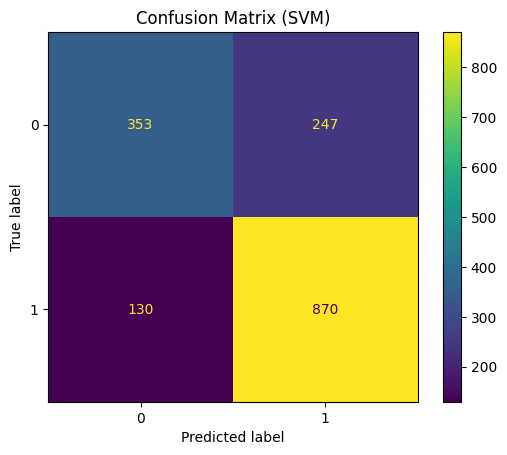

In [10]:
ConfusionMatrixDisplay.from_predictions(y_test, pred_svm)

plt.title("Confusion Matrix (SVM)")
plt.show()

In [11]:
y_semi = y.copy()

mask = np.random.rand(len(y_semi)) < 0.8
y_semi[mask] = -1

model = LabelSpreading()

model.fit(X, y_semi)

pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.72      0.61      0.66       600
           1       0.78      0.86      0.82      1000

    accuracy                           0.76      1600
   macro avg       0.75      0.73      0.74      1600
weighted avg       0.76      0.76      0.76      1600



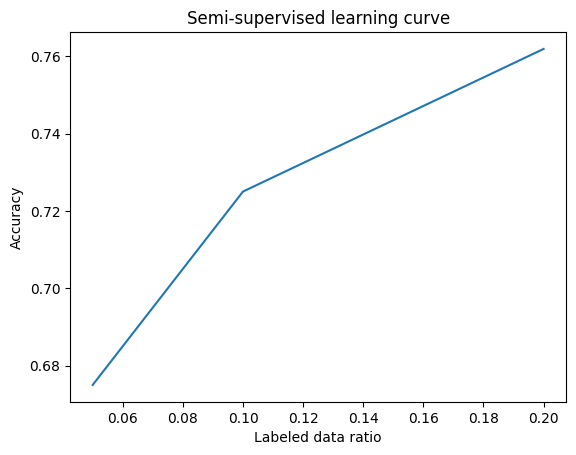

In [12]:
sizes = [0.05, 0.1, 0.2]

scores = []

for s in sizes:

    y_temp = y.copy()

    mask = np.random.rand(len(y_temp)) > s
    y_temp[mask] = -1

    model = LabelSpreading()

    model.fit(X, y_temp)

    pred = model.predict(X_test)

    from sklearn.metrics import accuracy_score

    scores.append(accuracy_score(y_test, pred))


plt.plot(sizes, scores)
plt.xlabel("Labeled data ratio")
plt.ylabel("Accuracy")
plt.title("Semi-supervised learning curve")
plt.show()

### Phân tích lỗi của mô hình phân lớp

Dựa vào confusion matrix, có thể thấy mô hình nhận diện các review tích cực tốt hơn so với review tiêu cực.

Nguyên nhân là vì trong dataset số lượng review tích cực nhiều hơn review tiêu cực, nên mô hình học được các đặc trưng của review tích cực tốt hơn.

Một số lỗi phân loại xảy ra khi review chứa cả ý kiến tích cực và tiêu cực. Ví dụ:

"Nice room but the bathroom was dirty."

Trong trường hợp này review vừa có yếu tố tốt vừa có yếu tố xấu nên mô hình có thể phân loại sai.

Ngoài ra các review rất ngắn như:

"Nice hotel"  
"Good stay"

không cung cấp đủ thông tin để mô hình xác định chính xác cảm xúc của review.